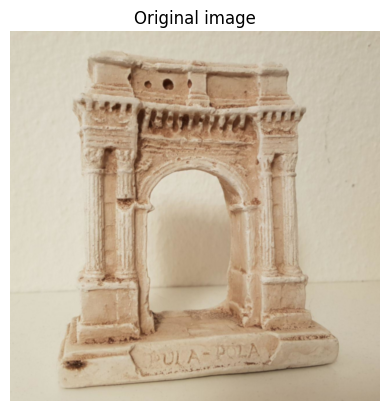

In [5]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("image.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Original image")
plt.axis("off")

plt.savefig("1_original.png", bbox_inches='tight')
plt.show()

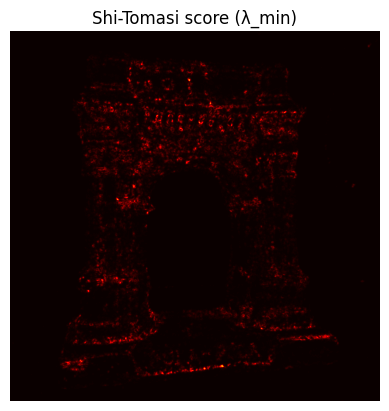

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("image.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)

Ix = cv2.Sobel(gray, cv2.CV_64F, 1, 0)
Iy = cv2.Sobel(gray, cv2.CV_64F, 0, 1)

Ixx = cv2.GaussianBlur(Ix*Ix,(7,7),1)
Iyy = cv2.GaussianBlur(Iy*Iy,(7,7),1)
Ixy = cv2.GaussianBlur(Ix*Iy,(7,7),1)

trace = Ixx + Iyy
det = Ixx*Iyy - Ixy**2

lambda_min = trace/2 - np.sqrt((trace/2)**2 - det)

plt.imshow(lambda_min, cmap="hot")
plt.title("Shi-Tomasi score (λ_min)")
plt.axis("off")

plt.savefig("2_shi_tomasi_score.png", bbox_inches='tight')
plt.show()

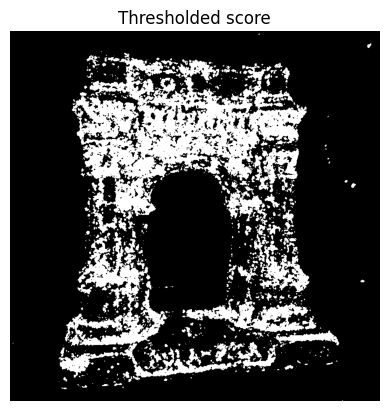

In [7]:
threshold = 0.01 * lambda_min.max()

thresholded = lambda_min > threshold

plt.imshow(thresholded, cmap="gray")
plt.title("Thresholded score")
plt.axis("off")

plt.savefig("3_thresholded.png", bbox_inches='tight')
plt.show()